In [382]:
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

trading = pd.read_csv("TRD_Dalym.csv")   # Daily total value of shares
index = pd.read_csv("IDX_Idxtrd.csv")      # (000001) daily price
margin = pd.read_csv("CHN_Stkmt_dsummary.csv")   # Daily margin trading and securities lending balance
bond = pd.read_csv("BND_TreasYield.csv")   # Daily 10-year government bond yield
csi = pd.read_stata("CSI300 PE and dividend yield.dta")
fund = pd.read_stata("daily fund shares.dta")
stock = pd.read_stata("daily representative price.dta")

trading.columns = ['markettype','date', 'trading_value']
index.columns = ['Indexcd','date', 'close']
margin.columns = ['Exchangecode','date', 'margin_balance']
bond.columns = ['date', 'yield']
csi.columns = ['date','pe', 'div_yield']
fund.columns = ['fundcode', 'shares', 'date']    
stock.columns = ['code','date', 'close']

In [383]:
for df in [trading, margin, index, bond, csi, stock, fund]:
    df['date'] = pd.to_datetime(df['date'])
    
episodes = {
    "2015": ("2014-06-19", "2015-06-12"),
    "2021": ("2019-01-04", "2021-02-18"),
    "current": ("2024-09-18", "2026-03-09")
}


In [384]:
def sum_by_date(df, date_col='date', value_col='value'):
    
    # 2. 按日期分组，对数值列求和
    # groupby(date_col) 把同一天的行打包
    # [value_col].sum() 把打包里的数全加起来
    df_sum = df.groupby(date_col)[value_col].sum().reset_index()
    return df_sum

In [385]:
#Trading Value Ratio
def trading_value_ratio(df, start, end):
    df_period = df[(df['date'] >= start) & (df['date'] <= end)].sort_values('date')
    
    start_val = df_period.iloc[0]['trading_value']
    end_val = df_period.iloc[-1]['trading_value']
    tv_ratio = end_val / start_val
    return tv_ratio


In [386]:
#Maximum Trading Value Ratio Within the Bull Market
#a
def max_trading_ratio(df, start, end):
    df_period = df[(df['date'] >= start) & (df['date'] <= end)]
    
    start_val = df_period.iloc[0]['trading_value']
    max_val = df_period['trading_value'].max()
    
    return max_val / start_val
#b
def get_peak_date(df, start, end):
    df_period = df[(df['date'] >= start) & (df['date'] <= end)]
    
    peak_row = df_period.loc[df_period['trading_value'].idxmax()]
    
    return peak_row['date']

def index_return(index_df, start, peak, end):
    index_df = index_df.sort_values('date')
    
    P_start = index_df[index_df['date'] == start]['close'].values[0]
    P_peak = index_df[index_df['date'] == peak]['close'].values[0]
    P_end = index_df[index_df['date'] == end]['close'].values[0]
    
    before = P_peak / P_start - 1
    after = P_end / P_peak - 1
    
    return before, after

In [387]:
#Margin Trading Balance Ratio
def margin_ratio(df, start, end):
    df_period = df[(df['date'] >= start) & (df['date'] <= end)].sort_values('date')
    
    start_val = df_period.iloc[0]['margin_balance']
    end_val = df_period.iloc[-1]['margin_balance']
    
    return end_val / start_val

In [388]:
#New Issuance of Equity-Oriented Funds
def fund_ratio(df, start, end):
    
    f = df[(df['date'] >= start) & (df['date'] <= end)].copy()
    f['shares'] = pd.to_numeric(f['shares'], errors='coerce')
    f['month'] = f['date'].dt.to_period('M')
    m = f.groupby('month')['shares'].sum().sort_index()
    if len(m) < 1: 
        return None
    start_m = m.iloc[0]
    end_m = m.iloc[-1]
    
    return end_m / start_m if start_m != 0 else None


In [389]:
# CSI 300 ERP
def compute_erp(csi, bond):
    df = csi.merge(bond, on='date')
    df['erp'] = 1 / df['pe'] - df['yield']
    return df

def erp_stats(df, start, end):
    d = df[(df['date'] >= start) & (df['date'] <= end)].sort_values('date')
    hist = df[df['date'] < start]
    
    level = d.iloc[-1]['erp'] - d.iloc[0]['erp']
    
    pct_start = (hist['erp'] < d.iloc[0]['erp']).mean()
    pct_end = (hist['erp'] < d.iloc[-1]['erp']).mean()
    
    return level, pct_start, pct_end


In [390]:
# CSI 300 Dividend Yield - Bond Yield Spread
def spread_stats(df, start, end):
    df['spread'] = df['div_yield'] - df['yield']
    d = df[(df['date'] >= start) & (df['date'] <= end)].sort_values('date')
    hist = df[df['date'] < start]
    
    level = d.iloc[-1]['spread'] - d.iloc[0]['spread']
    
    pct_start = (hist['spread'] < d.iloc[0]['spread']).mean()
    pct_end = (hist['spread'] < d.iloc[-1]['spread']).mean()
    
    return level, pct_start, pct_end

In [391]:
#Price Change of Representative Stocks
def stock_return(df, code, start, end):
    s = df[(df['code'] == code) &
              (df['date'] >= start) &
              (df['date'] <= end)].sort_values('date')
    return s.iloc[-1]['close'] / s.iloc[0]['close'] - 1

#def best_broker(df, start, end):
    d = df[(df['date'] >= start) & (df['date'] <= end)]
    exclude_codes = [600570, 300059]          
    d = d[~d['code'].isin(exclude_codes)]
    returns = d.groupby('code').apply(
        lambda x: x.sort_values('date').iloc[-1]['close'] /
                  x.sort_values('date').iloc[0]['close'] - 1
    )
    
    return returns.max()

def best_broker(df, start, end):
    
    # 剔除东方财富 (300059) 和恒生电子 (600570)
    exclude = ['300059', '600570']
    df = df[~df['code'].isin(exclude)]
    
    # 计算每只股票的区间涨幅
    def calc_return(x):
        x = x.sort_values('date')
        if len(x) < 2:
            return np.nan
        p_start = x.iloc[0]['close']
        p_end = x.iloc[-1]['close']
        return (p_end / p_start) - 1
    
    returns = df.groupby('code').apply(calc_return).dropna()
    if returns.empty:
        return None, None
    best_code = returns.idxmax()
    best_return = returns.max()
    return best_code, best_return


In [392]:
results = {}

for name, (start, end) in episodes.items():
    
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    
    trading = sum_by_date(trading, date_col='date', value_col='trading_value')
    margin = sum_by_date(margin, date_col='date', value_col='margin_balance')
    # Trading Value
    tv_ratio = trading_value_ratio(trading, start, end)
    #Max Trading Value Ratio
    max_tv_ratio = max_trading_ratio(trading, start, end)
    peak_date = get_peak_date(trading, start, end) 
    # b Index return
    before, after = index_return(index, start, peak_date, end)
    
    # Margin Trading Balance Ratio
    m_ratio = margin_ratio(margin, start, end)
    
    f = fund_ratio(fund, start, end)
    erp_df = compute_erp(csi, bond)
    erp_level, erp_ps, erp_pe = erp_stats(erp_df, start, end)
    sp_level, sp_ps, sp_pe = spread_stats(erp_df, start, end)
    
    em = stock_return(stock, '300059', start, end)
    hs = stock_return(stock, '600570', start, end)
    bc, br = best_broker(stock, start, end)
    
    results[name] = {
        "Trading Value Ratio": tv_ratio,
        "Max Trading Value Ratio": max_tv_ratio,
        "Index Before Peak": before,
        "Index After Peak": after,
        "Margin Ratio": m_ratio,
        "Fund Ratio": f,
        "ERP Change": erp_level,
        "ERP Percentile Start": erp_ps,
        "ERP Percentile End": erp_pe,
        "Spread Change": sp_level,
        "Spread Percentile Start": sp_ps,
        "Spread Percentile End": sp_pe,
        "East Money Return": em,
        "Hundsun Return": hs,
        "Best Broker Return": br
    }
    
results_df = pd.DataFrame(results).T
results_df.index.name = 'Date'
display(results_df)
results_df.to_csv('output.csv', index=True,float_format='%.6f')

-1.3882249420553212


/var/folders/1c/m_xj0h9x5pl4cnk4ptg44l5r0000gn/T/ipykernel_62333/1232156332.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  returns = df.groupby('code').apply(calc_return).dropna()
/var/folders/1c/m_xj0h9x5pl4cnk4ptg44l5r0000gn/T/ipykernel_62333/1232156332.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  returns = df.groupby('code').apply(calc_return).dropna()
/var/folders/1c/m_xj0h9x5pl4cnk4ptg44l5r0000gn/T

,Trading Value Ratio,Max Trading Value Ratio,Index Before Peak,Index After Peak,Margin Ratio,Fund Ratio,ERP Change,ERP Percentile Start,ERP Percentile End,Spread Change,Spread Percentile Start,Spread Percentile End,East Money Return,Hundsun Return,Best Broker Return
Date,,,,,,,,,,,,,,,
2015,11.280498,13.555876,1.283039,0.118193,5.500002,3.205319,-2.650106,0.887440,0.098759,-3.9917,0.972509,0.103573,6.254386,4.840773,2.126679
2021,3.369130,5.399848,0.330224,0.098651,2.198825,19.921282,-2.437550,0.956869,0.269932,-3.5180,0.993586,0.180671,1.941360,0.907557,2.126679
current,5.543180,8.275323,0.518464,-0.007147,1.926988,1.373447,-1.388225,0.967726,0.636183,-2.1369,0.999437,0.740042,1.035475,0.738693,2.126679


In [393]:
start = pd.to_datetime("2024-09-18")
end = pd.to_datetime("2026-03-09")

for df in [trading, margin, index, bond, csi, stock, fund]:
    df = df[(df['date'] >= start) & (df['date'] <= end)]

trading = trading.sort_values('date').set_index('date')    
tv_series = trading['trading_value'] / trading['trading_value'].iloc[0]
max_tv_series = trading['trading_value'].cummax() / trading['trading_value'].iloc[0]

margin = margin.sort_values('date').set_index('date')
margin['margin_ratio'] = margin['margin_balance'] / margin['margin_balance'].iloc[0]

fund = fund.sort_values('date')
fund['year_month'] = fund['date'].dt.to_period('M')
monthly_fund = fund.groupby('year_month')['shares'].sum().reset_index()
monthly_fund['date'] = monthly_fund['year_month'].dt.start_time
monthly_fund['cumulative_ratio'] = monthly_fund['shares'].cumsum() / monthly_fund['shares'].iloc[0]

combined = pd.concat([csi[['pe', 'div_yield']], bond[['yield']]], axis=1, join='inner')
combined.columns = ['pe', 'div_yield', 'bond_yield']
combined['bond_yield'] = combined['bond_yield'] / 100  # 转换为小数
combined['erp'] = 1 / combined['pe'] - combined['bond_yield']

combined['dy_minus_bond'] = combined['div_yield'] - combined['bond_yield']


best_code, best_ret = best_broker(stock, start, end)
print(f"涨幅最大的券商股：{best_code}，涨幅：{best_ret:.2%}")

# 计算三只股票的累计收益率
stocks_pivot = stock.pivot(index='date', columns='code', values='close')
stocks_pivot = stocks_pivot.sort_index()

def stock_series(code):
    df = stock[stock['code'] == code].loc[start:end]
    s = df['close'] / df['close'].iloc[0] - 1
    s.index = df.index
    return s
# 选取需要的股票
target_codes = ['300059', '600570', best_code]
returns_df = pd.DataFrame({code: stock_series(code) for code in target_codes})
returns_df.columns = ['Eastmoney', 'Hundsun', f'brokerage({best_code})']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

# 1. 成交额比值
ax = axes[0]
ax.plot(tv_series.index, tv_series.values, label='Trading Value Ratio', color='blue')
ax.legend()
ax.set_title('Ratio')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Maximum Trading Value Ratio
ax = axes[1]
ax.plot(max_tv_series.index, max_tv_series.values, label='Maximum Trading Value Ratio', color='red', linestyle='--')
ax.legend()
ax.set_title('Ratio')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Margin Trading Balance Ratio
ax = axes[2]
ax.plot(margin.index, margin['margin_ratio'], color='green')
ax.set_title('Margin Trading Balance Ratio')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# 新发基金份额（月度）
ax = axes[3]
ax.plot(monthly_fund.index, monthly_fund['cumulative_ratio'], color='red', marker='o')
ax.legend()
ax.set_title('New Fund Issuance Ratio')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# ERP
ax = axes[4]
ax.plot(combined.index, combined['erp'], color='purple')
ax.set_title('CSI 300 ERP')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# 股息率减国债收益率
ax = axes[5]
ax.plot(combined.index, combined['dy_minus_bond'], color='orange')
ax.set_title('CSI 300 Dividend Yield Minus 10-Year Government Bond Yield')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.figure(figsize=(12, 6))
for col in returns_df.columns:
    plt.plot(returns_df.index, returns_df[col], label=col)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.legend()
plt.title('Price Change of Representative Stocks')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

涨幅最大的券商股：002945，涨幅：212.67%


/var/folders/1c/m_xj0h9x5pl4cnk4ptg44l5r0000gn/T/ipykernel_62333/1232156332.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  returns = df.groupby('code').apply(calc_return).dropna()


TypeError: '<' not supported between instances of 'int' and 'Timestamp'

/var/folders/1c/m_xj0h9x5pl4cnk4ptg44l5r0000gn/T/ipykernel_62333/3196820411.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fund_monthly = fund['shares'].resample('M').sum()  # 按月求和（如果是基金份额新增量的话）
/var/folders/1c/m_xj0h9x5pl4cnk4ptg44l5r0000gn/T/ipykernel_62333/3196820411.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  total_returns = period_data.groupby('code').apply(


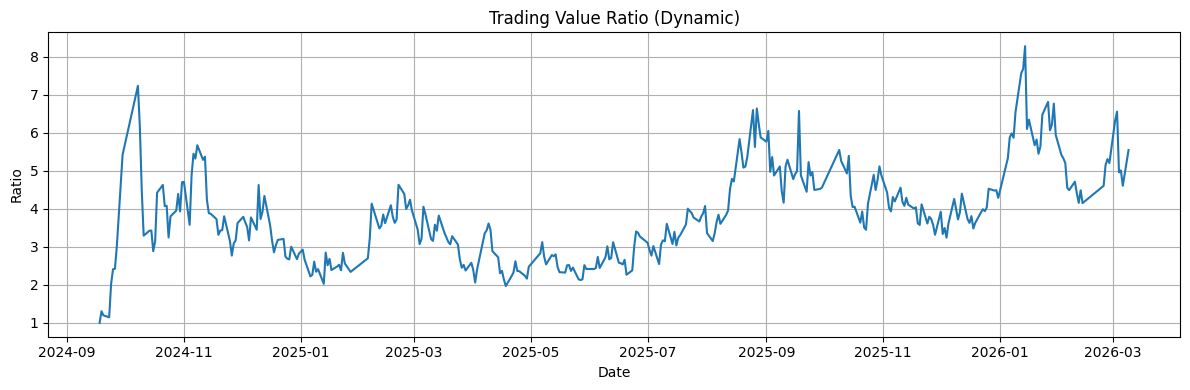

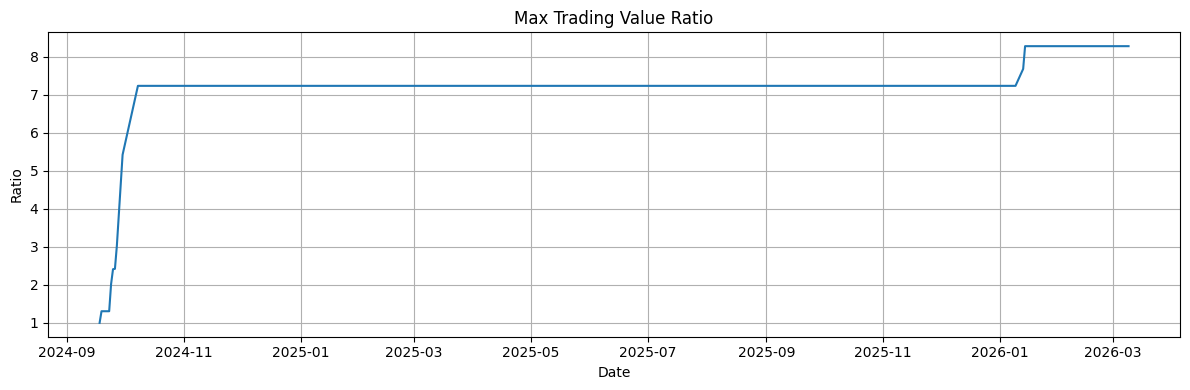

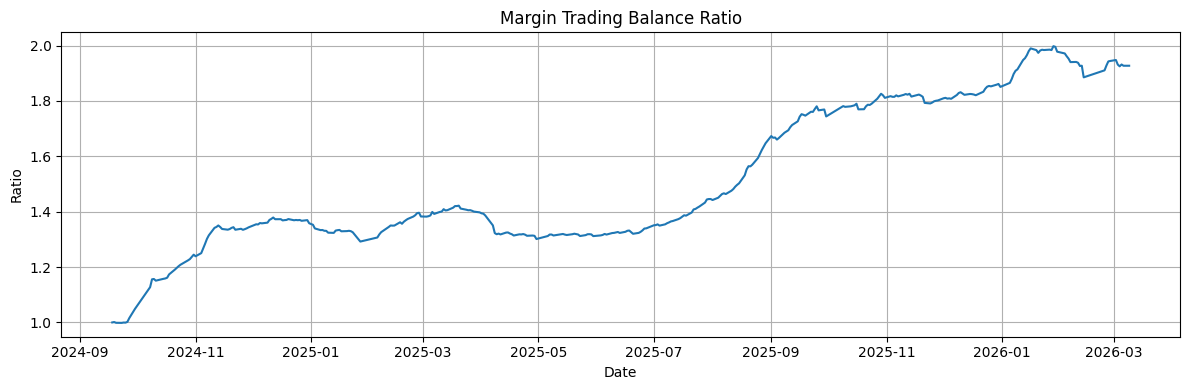

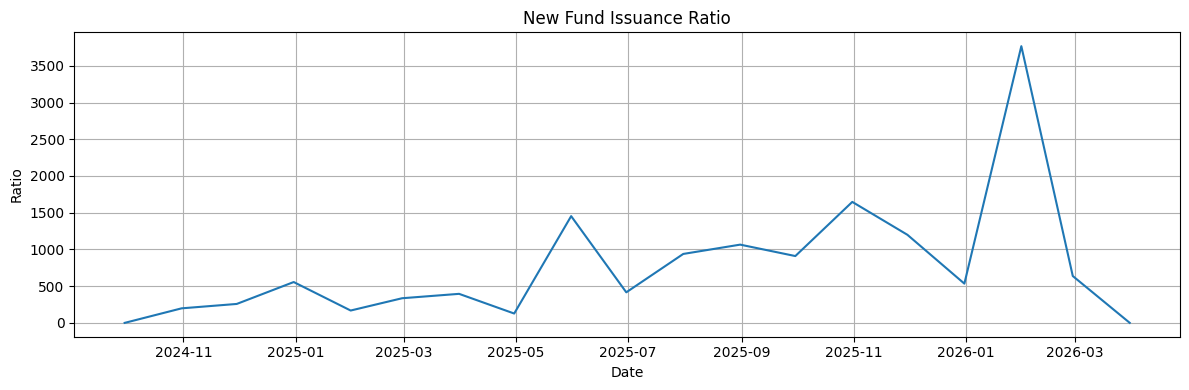

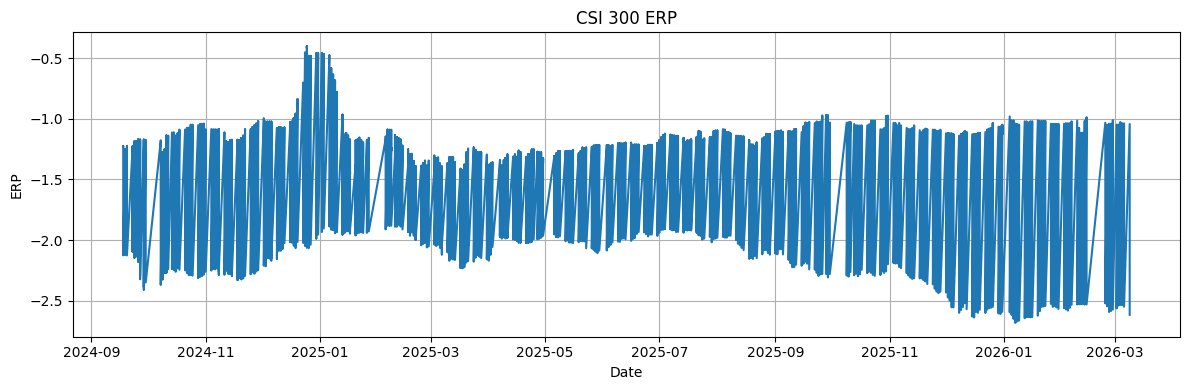

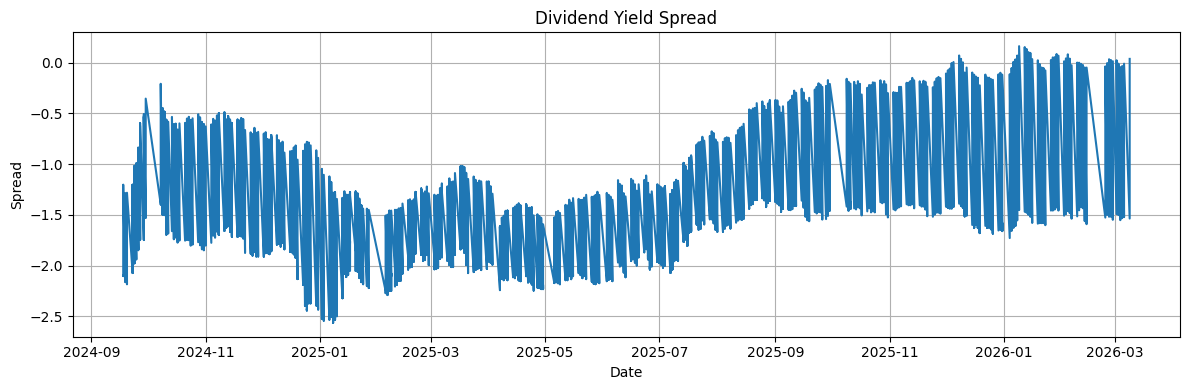

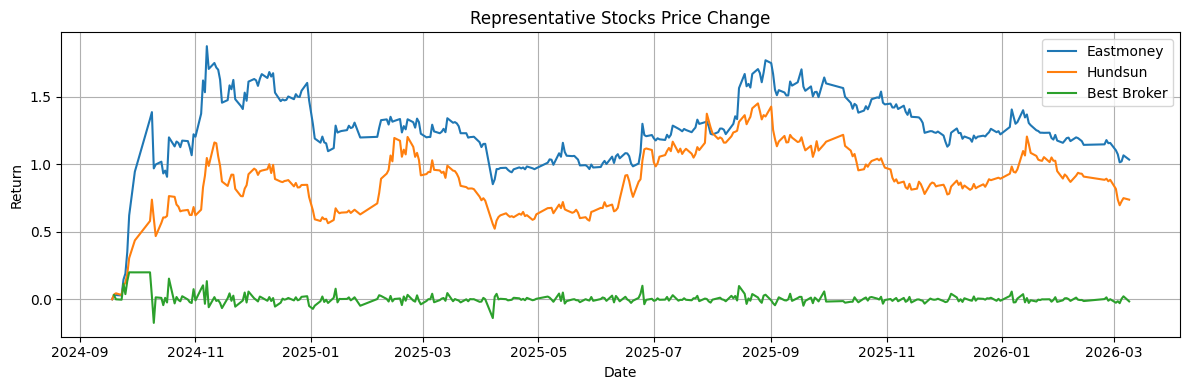

In [ ]:
# --- 时间区间 ---
start = pd.to_datetime("2024-09-18")
end = pd.to_datetime("2026-03-09")
trading = sum_by_date(trading, date_col='date', value_col='trading_value')
    
margin = sum_by_date(margin, date_col='date', value_col='margin_balance')

# Trading Value
tv_ratio = trading_value_ratio(trading, start, end)
# Max Trading Value Ratio
max_tv_ratio = max_trading_ratio(trading, start, end)
peak_date = get_peak_date(trading, start, end)
# Index return
before, after = index_return(index, start, peak_date, end)

# Margin Trading Balance Ratio
m_ratio = margin_ratio(margin, start, end)

f = fund_ratio(fund, start, end)
erp_df = compute_erp(csi, bond)
erp_level, erp_ps, erp_pe = erp_stats(erp_df, start, end)
sp_level, sp_ps, sp_pe = spread_stats(erp_df, start, end)

em = stock_return(stock, '300059', start, end)
hs = stock_return(stock, '600570', start, end)
bc, br = best_broker(stock, start, end)
# --- 1. 数据预处理 ---
trading = trading.set_index('date').sort_index()
margin = margin.set_index('date').sort_index()
fund = fund.set_index('date').sort_index()
stock = stock.set_index('date').sort_index()

# 截取区间
trading = trading.loc[start:end]
margin = margin.loc[start:end]
fund = fund.loc[start:end]
stock = stock.loc[start:end]
# --- 2. 构造 time-series 指标 ---

# 1) Trading Value Ratio (动态)
tv_series = trading['trading_value'] / trading['trading_value'].iloc[0]


# 2) Max Trading Value Ratio
max_tv_series = trading['trading_value'].cummax() / trading['trading_value'].iloc[0]

# 3) Margin Ratio
margin_series = margin['margin_balance'] / margin['margin_balance'].iloc[0]

# 4) Fund Ratio
fund_monthly = fund['shares'].resample('M').sum()  # 按月求和（如果是基金份额新增量的话）
fund_series = fund_monthly / fund_monthly.iloc[0]

# 5) ERP
erp_df = erp_df.set_index('date').loc[start:end]
erp_series = erp_df['erp']

# 6) Spread
yield_series = erp_df['yield'] - erp_df['div_yield']

# 7) 股票收益函数
def stock_series(code):
    df = stock[stock['code'] == code].loc[start:end]
    s = df['close'] / df['close'].iloc[0] - 1
    s.index = df.index
    return s

eastmoney_series = stock_series('300059')
hundsun_series = stock_series('600570')

def best_series(stock_df, start_date, end_date):
    period_data = stock_df.loc[start_date:end_date]
    exclude_codes = [600570, 300059]          
    period_data = period_data[~period_data['code'].isin(exclude_codes)]
    total_returns = period_data.groupby('code').apply(
        lambda x: x['close'].iloc[-1] / x['close'].iloc[0] - 1
    )
    best_code = total_returns.idxmax()
    # 获取该股票全部历史数据（按日期排序）
    best_stock = stock_df[stock_df['code'] == best_code].sort_index()
    # 返回收益率序列（日收益率）
    best_series = best_stock['close'].pct_change()
    return best_series

broker_series = best_series (stock, start, end)

# --- 3. 绘图函数（核心简化） ---
def plot_single(series, title, ylabel):
    plt.figure(figsize=(12,4))
    plt.plot(series.index, series.values)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- 4. 画 1-6 张图 ---
plot_single(tv_series, 'Trading Value Ratio (Dynamic)', 'Ratio')
plot_single(max_tv_series, 'Max Trading Value Ratio', 'Ratio')
plot_single(margin_series, 'Margin Trading Balance Ratio', 'Ratio')
plot_single(fund_series, 'New Fund Issuance Ratio', 'Ratio')
plot_single(erp_series, 'CSI 300 ERP', 'ERP')
plot_single(yield_series, 'Dividend Yield Spread', 'Spread')

# --- 5. 第 7 张图（三只股票一起） ---
plt.figure(figsize=(12,4))
plt.plot(eastmoney_series.index, eastmoney_series.values, label='Eastmoney')
plt.plot(hundsun_series.index, hundsun_series.values, label='Hundsun')
plt.plot(broker_series.index, broker_series.values, label='Best Broker')
plt.title('Representative Stocks Price Change')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()